=== Step 1: system parameters ===
Stage 1: R=1000.0 ohm, C=2.7566e-07 F, tau=2.7566e-04 s, analytic phase=-60.0000 deg, |H|=0.5000
Stage 2: R=2200.0 ohm, C=1.2530e-07 F, tau=2.7566e-04 s, analytic phase=-60.0000 deg, |H|=0.5000
Stage 3: R=4700.0 ohm, C=5.8652e-08 F, tau=2.7566e-04 s, analytic phase=-60.0000 deg, |H|=0.5000
Analytic total: phase=-180.0000 deg, |Htot|=0.125000
dt/tau (worst case) = 0.0145, dt*omega = 0.0251 (both small -> Strang splitting should be very accurate)

=== Step 2: K / S decomposition ===
Eigenvalues of dissipative part S: [-6340.1496 -4026.0666 -1415.3315     0.         0.         0.
     0.       898.7515]
Per-step contraction factors r_i : [0.97146  0.980493 0.990786 0.996411 0.996411 0.996411 0.996411 1.      ]
Classical rescale factor per step g = 1.0036014757

=== Step 3: building one-step quantum circuit ===


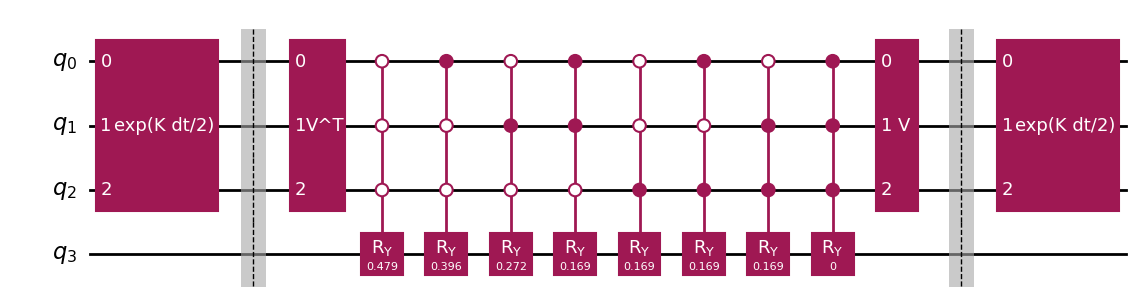


=== Step 4: verifying circuit against exact matrix math ===
||circuit (ancilla=0 block) - exact (K,S)-step||_F = 1.424e-15
Verification SUCCESS: the circuit exactly implements the dilated step.

=== Step 5: running the dilated Trotter evolution ===
Average per-step state fidelity              : 0.999358
Post-selection success probability at t=0.006s : 0.0000


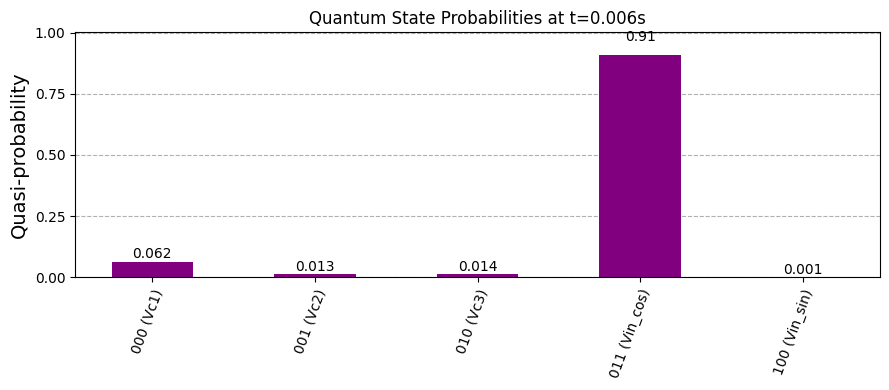


=== Step 7: measuring simulated phase shift per stage ===
Stage 1: quantum phase=-58.62 deg (|H|=0.4956)  |  scipy phase=-60.09 deg (|H|=0.4956)  |  analytic=-60.00 deg
Stage 2: quantum phase=-118.95 deg (|H|=0.2513)  |  scipy phase=-120.39 deg (|H|=0.2515)  |  analytic=-60.00 deg
Stage 3: quantum phase=-178.08 deg (|H|=0.1254)  |  scipy phase=-179.52 deg (|H|=0.1254)  |  analytic=-60.00 deg

Total output (stage 3) phase relative to Vin: -178.08 deg (target: -180.00 deg)

=== Step 8: generating final output graphs ===


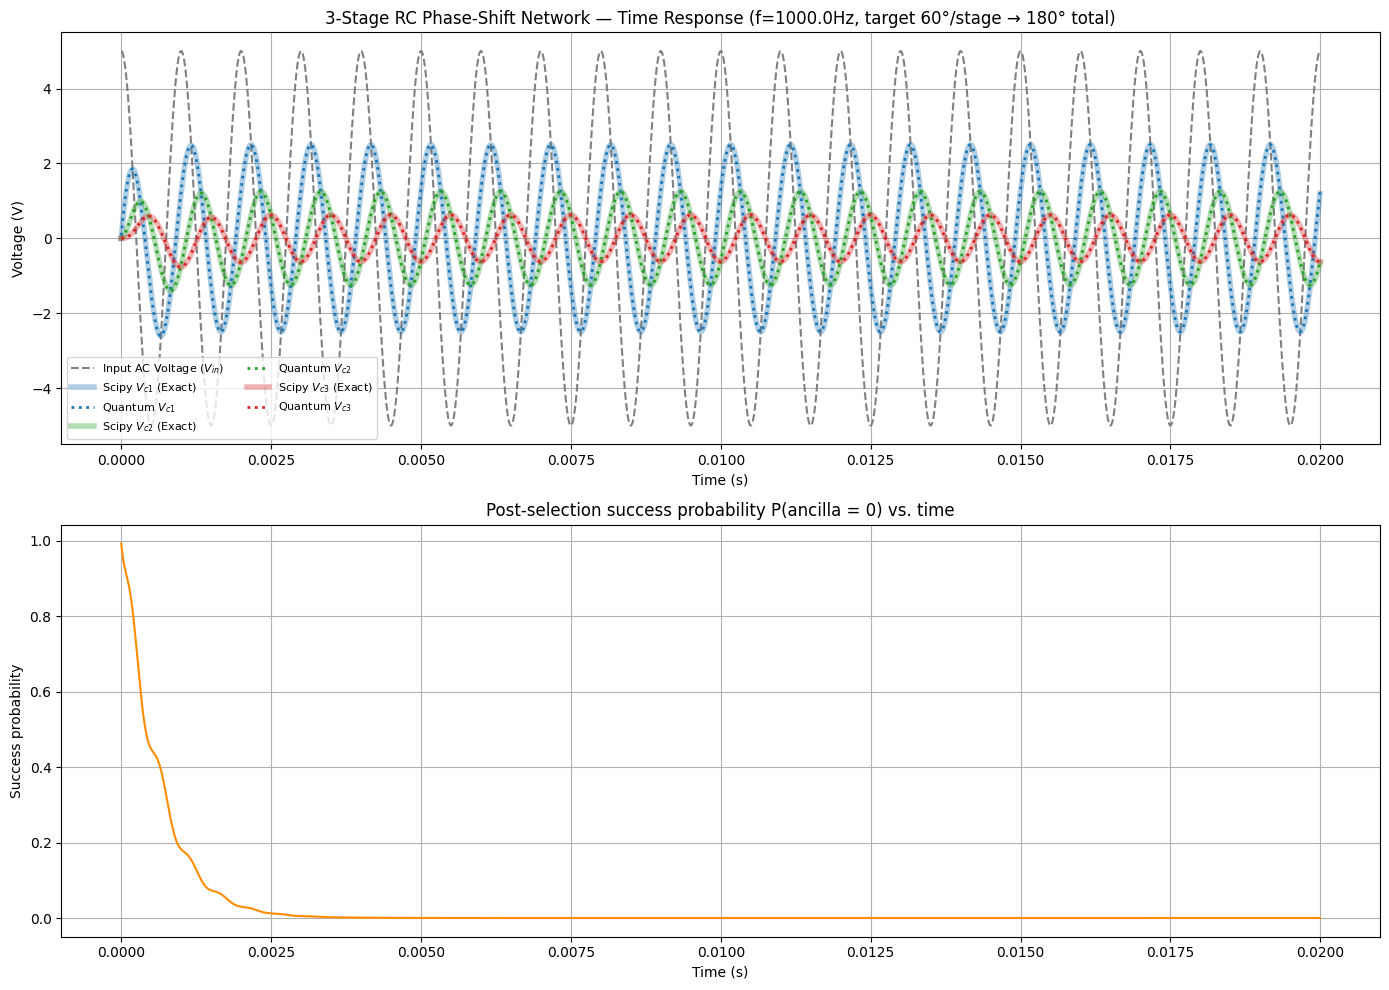


=== Final summary ===
Average per-step state fidelity   : 0.999358
Relative L2 error of Vc(t) (all 3 stages) : 2.533648e-02
Overall trajectory fidelity proxy : 0.949969
Simulated total phase shift (stage 3 vs Vin): -178.081 deg  (target: -180 deg)


In [1]:
"""
Trotterized 3-Stage RC Phase-Shift Network — Unitary Dilation Method
=======================================================================

CIRCUIT TOPOLOGY
-----------------
Three cascaded, BUFFERED single-pole RC lowpass stages: stage 1 is
driven by the AC source Vin(t)=V0*cos(wt); stage 2 is driven by stage
1's OWN output Vc1 (not by Vin directly); stage 3 is driven by stage
2's output Vc2. "Buffered" means each stage drives the next with an
ideal voltage source (no loading/current drawn back from the next
stage) -- this is the standard assumption behind the classic RC
phase-shift network and is exactly what makes each stage contribute
an independent, additive phase shift. (A directly-loaded resistive
ladder, where each stage draws real current from the previous one,
does NOT give a clean 60/60/60 split -- confirmed numerically while
deriving this: an unbuffered ladder's phases don't decouple into equal
increments no matter what R,C are chosen, because of extra
cross-loading terms in its state matrix.)

Each stage obeys its own single-pole ODE, chained to the previous
stage's output:
    dVc1/dt = (Vin - Vc1) / tau1
    dVc2/dt = (Vc1 - Vc2) / tau2
    dVc3/dt = (Vc2 - Vc3) / tau3
    tau_i = R_i * C_i

All three stages share the SAME driving frequency f0 but have
DIFFERENT R_i, C_i (as requested) chosen so that tau_i is IDENTICAL
across stages -- this is the only way to get an equal 60 deg phase
shift per stage while still using distinct component values:

    tau_needed = tan(60 deg) / w0

    Stage 1: R1=1000 ohm,  C1 solved from tau_needed
    Stage 2: R2=2200 ohm,  C2 solved from tau_needed
    Stage 3: R3=4700 ohm,  C3 solved from tau_needed

Each single stage contributes EXACTLY -60.0000 deg phase (analytically,
in steady state) and |H|=0.5 magnitude relative to ITS OWN input, so
the cascade accumulates to -60, -120, -180 deg at stages 1, 2, 3
respectively (checked numerically below against both the classical
ODE and the quantum simulation, after the initial transient settles).

STATE VECTOR (5 physical states, padded to 8 = 3 qubits)
------------------------------------------------------------
    x = [ Vc1, Vc2, Vc3, Vin_cos, Vin_sin, 0, 0, 0 ]

    dVc1/dt       = -Vc1/tau1 + Vin_cos/tau1
    dVc2/dt       = -Vc2/tau2 + Vc1/tau2
    dVc3/dt       = -Vc3/tau3 + Vc2/tau3
    dVin_cos/dt   = -omega * Vin_sin
    dVin_sin/dt   =  omega * Vin_cos

This is the direct 3-stage generalization of the single-stage
augmented state-space trick: each RC stage still only dissipates
into its OWN diagonal slot, but now A has genuine off-diagonal
couplings Vc1->Vc2 and Vc2->Vc3 (the cascade), on top of the
Vin_cos->Vc1 coupling from the original single-stage script. K and S
are recomputed for this new, larger, asymmetric A exactly the same
way as before -- the dilation method itself is agnostic to how many
coupled dissipative channels A has.

UNITARY DILATION METHOD (identical machinery to the single-stage case)
--------------------------------------------------------------------------
    K = (A - A^T)/2   -> exactly antisymmetric -> exp(K dt) EXACTLY unitary
    S = (A + A^T)/2   -> symmetric             -> non-unitary dissipative part,
                          embedded via a single ancilla qubit (dilation),
                          post-selected on ancilla = 0.

Strang splitting:  exp(K dt/2) . [S-dilation] . exp(K dt/2)
cancels the leading-order (first-order, O(dt^2)) commutator error
between the K and S sub-steps, from Baker-Campbell-Hausdorff:
    exp(K dt/2) exp(S dt) exp(K dt/2)
       = exp( (K+S)dt + O(dt^3) )
(the O(dt^2) term that would survive a naive exp(K dt)exp(S dt) product
is exactly cancelled by the symmetric split -- same reasoning as the
single-stage script, generalizes unchanged to any K,S split.)

S is diagonalized once per problem: S = V @ diag(lambda) @ V^T.
A sub-unitary block encoding can only ever shrink amplitude, so we
factor out the fastest-growing eigenmode as a classical scalar `g`
per step, and encode the remaining per-eigenmode factors
r_i = exp((lambda_i - lambda_max)*dt) <= 1 as controlled-RY rotations
onto the ancilla, post-selected on ancilla = 0.

Now needs a 3-qubit MAIN register (8-dim, holding the 5 physical
states + 3 padding zeros) + 1 ancilla = 4 qubits total for the circuit.

Run this in a Jupyter notebook (uses %matplotlib inline / display,
same as the single-stage script).
"""

# %matplotlib inline
import numpy as np
import scipy.linalg
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.circuit.library import UnitaryGate, RYGate
from qiskit.visualization import plot_histogram
from IPython.display import display

# ==========================================================
# 1. System parameters — three DIFFERENT (R,C) pairs, same tau
#    (this is the only way to get an equal 60 deg/stage split
#    while using distinct component values, as verified below)
# ==========================================================
f0 = 1000.0
omega = 2 * np.pi * f0
V0 = 5.0

target_deg_per_stage = 60.0
tau_needed = np.tan(np.radians(target_deg_per_stage)) / omega

R1 = 1000.0;  C1 = tau_needed / R1
R2 = 2200.0;  C2 = tau_needed / R2
R3 = 4700.0;  C3 = tau_needed / R3
tau1, tau2, tau3 = R1 * C1, R2 * C2, R3 * C3

t_max = 0.02
dt = 4e-6
times = np.arange(0, t_max, dt)
n_steps = len(times)
target_time = 0.006
target_step = int(target_time / dt)

print("=== Step 1: system parameters ===")
for i, (R, C, tau) in enumerate([(R1, C1, tau1), (R2, C2, tau2), (R3, C3, tau3)], start=1):
    H_i = 1 / (1 + 1j * omega * tau)
    print(f"Stage {i}: R={R} ohm, C={C:.4e} F, tau={tau:.4e} s, "
          f"analytic phase={np.degrees(np.angle(H_i)):.4f} deg, |H|={np.abs(H_i):.4f}")
Htot_analytic = 1.0
for tau in (tau1, tau2, tau3):
    Htot_analytic *= 1 / (1 + 1j * omega * tau)
print(f"Analytic total: phase={np.degrees(np.angle(Htot_analytic)):.4f} deg, "
      f"|Htot|={np.abs(Htot_analytic):.6f}")
print(f"dt/tau (worst case) = {dt/min(tau1,tau2,tau3):.4f}, dt*omega = {dt*omega:.4f} "
      f"(both small -> Strang splitting should be very accurate)")

# ==========================================================
# 2. Augmented generator A (5 physical states, padded to 8 = 3 qubits)
#    x = [Vc1, Vc2, Vc3, Vin_cos, Vin_sin, 0, 0, 0]
# ==========================================================
A_matrix = np.zeros((8, 8))
A_matrix[0, 0] = -1 / tau1; A_matrix[0, 3] = 1 / tau1          # dVc1 = (Vin_cos - Vc1)/tau1
A_matrix[1, 1] = -1 / tau2; A_matrix[1, 0] = 1 / tau2          # dVc2 = (Vc1 - Vc2)/tau2
A_matrix[2, 2] = -1 / tau3; A_matrix[2, 1] = 1 / tau3          # dVc3 = (Vc2 - Vc3)/tau3
A_matrix[3, 4] = -omega
A_matrix[4, 3] = omega
# rows/cols 5,6,7 stay zero (padding to fill the 3-qubit / 8-dim register)

print("\n=== Step 2: K / S decomposition ===")
K = (A_matrix - A_matrix.T) / 2
S = (A_matrix + A_matrix.T) / 2

lam, V_eig = np.linalg.eigh(S)
lam_max = np.max(lam)
r = np.exp((lam - lam_max) * dt)
g_step = np.exp(lam_max * dt)

print("Eigenvalues of dissipative part S:", np.round(lam, 4))
print("Per-step contraction factors r_i :", np.round(r, 6))
print(f"Classical rescale factor per step g = {g_step:.10f}")

R_half = scipy.linalg.expm(K * dt / 2)
thetas = 2 * np.arccos(np.clip(r, -1.0, 1.0))

# ==========================================================
# 3. One Strang step as an actual quantum circuit
#     (3 main qubits + 1 ancilla) — used for drawing + verification
# ==========================================================
print("\n=== Step 3: building one-step quantum circuit ===")

def build_one_step_circuit():
    qc = QuantumCircuit(4, name="strang_step")  # qubits 0,1,2 = main ; qubit 3 = ancilla
    main_qubits = [0, 1, 2]
    ancilla = 3

    qc.append(UnitaryGate(R_half, label="exp(K dt/2)"), main_qubits)
    qc.barrier()

    qc.append(UnitaryGate(V_eig.T, label="V^T"), main_qubits)
    for i, theta in enumerate(thetas):
        qc.append(RYGate(theta).control(3, ctrl_state=i), main_qubits + [ancilla])
    qc.append(UnitaryGate(V_eig, label="V"), main_qubits)
    qc.barrier()

    qc.append(UnitaryGate(R_half, label="exp(K dt/2)"), main_qubits)
    return qc

one_step_qc = build_one_step_circuit()
display(one_step_qc.draw(output='mpl', style='iqp'))

# ==========================================================
# 4. Matrix verification: circuit vs. exact math
# ==========================================================
print("\n=== Step 4: verifying circuit against exact matrix math ===")
full_unitary = Operator(one_step_qc).data       # 16x16 unitary (main ⊗ ancilla)
sub_block = full_unitary[0:8, 0:8]               # ancilla start = end = 0 block

exact_full_step = R_half @ (V_eig @ np.diag(r) @ V_eig.T) @ R_half
difference = np.linalg.norm(sub_block - exact_full_step)
print(f"||circuit (ancilla=0 block) - exact (K,S)-step||_F = {difference:.3e}")
if difference < 1e-8:
    print("Verification SUCCESS: the circuit exactly implements the dilated step.")
else:
    print("Verification FAILED — check qubit ordering / ctrl_state convention.")

# ==========================================================
# 5. Time evolution: exact classical propagation matching the circuit
#     (reuse precomputed matrices verified in step 4, same as the
#      single-stage script's approach — rebuilding the circuit
#      thousands of times would be extremely slow)
# ==========================================================
print("\n=== Step 5: running the dilated Trotter evolution ===")

def rc3_deriv(x, t):
    Vin = V0 * np.cos(omega * t)
    Vc1, Vc2, Vc3 = x
    return [(Vin - Vc1) / tau1, (Vc1 - Vc2) / tau2, (Vc2 - Vc3) / tau3]

Vc_scipy = odeint(rc3_deriv, [0.0, 0.0, 0.0], times)   # columns: Vc1,Vc2,Vc3
Vin_scipy = V0 * np.cos(omega * times)

state = np.array([0.0, 0.0, 0.0, V0, 0.0, 0.0, 0.0, 0.0])  # physical + padding, stays exactly real
classical_gain = 1.0
initial_norm = np.linalg.norm(state)

Vc_quantum = np.zeros((n_steps, 3))
success_prob = np.zeros(n_steps)
fidelities = np.zeros(n_steps)
target_probabilities = {}

for i in range(n_steps):
    state = R_half @ state
    state = V_eig @ (r * (V_eig.T @ state))
    state = R_half @ state
    classical_gain *= g_step

    Vc_quantum[i, :] = classical_gain * state[0:3]
    success_prob[i] = (np.linalg.norm(state) / initial_norm) ** 2

    exact_vec = np.array([
        Vc_scipy[i, 0], Vc_scipy[i, 1], Vc_scipy[i, 2],
        V0 * np.cos(omega * times[i]), V0 * np.sin(omega * times[i]),
        0.0, 0.0, 0.0
    ])
    exact_norm = np.linalg.norm(exact_vec)
    exact_unit = exact_vec / exact_norm if exact_norm > 0 else exact_vec
    quantum_full = classical_gain * state
    quantum_unit = quantum_full / max(np.linalg.norm(quantum_full), 1e-15)
    fidelities[i] = float(np.dot(exact_unit, quantum_unit)) ** 2

    if i == target_step:
        probs = (state / np.linalg.norm(state)) ** 2
        target_probabilities = {
            '000 (Vc1)': float(probs[0]),
            '001 (Vc2)': float(probs[1]),
            '010 (Vc3)': float(probs[2]),
            '011 (Vin_cos)': float(probs[3]),
            '100 (Vin_sin)': float(probs[4]),
            '101 (pad)': float(probs[5]),
            '110 (pad)': float(probs[6]),
            '111 (pad)': float(probs[7]),
        }

print(f"Average per-step state fidelity              : {np.mean(fidelities):.6f}")
print(f"Post-selection success probability at t={target_time}s : {success_prob[target_step]:.4f}")

# ==========================================================
# 6. Histogram at target time
# ==========================================================
clean_probs = {k: v for k, v in target_probabilities.items() if v > 1e-10}
display(plot_histogram(clean_probs, title=f"Quantum State Probabilities at t={target_time}s",
                        color='purple', figsize=(9, 4)))

# ==========================================================
# 7. Phase-shift verification: measure actual simulated phase
#    of each stage output relative to Vin, using steady-state
#    cycles (skip initial transient)
# ==========================================================
print("\n=== Step 7: measuring simulated phase shift per stage ===")

def measure_phase(vc_signal, vin_signal, t_arr, w, skip_time):
    mask = t_arr >= skip_time
    t_s = t_arr[mask]
    vc_s = vc_signal[mask]
    vin_s = vin_signal[mask]
    # in-phase / quadrature demodulation against the known drive frequency
    I_vc = np.mean(vc_s * np.cos(w * t_s)) * 2
    Q_vc = np.mean(vc_s * np.sin(w * t_s)) * 2
    phase_vc = np.degrees(np.arctan2(-Q_vc, I_vc))
    mag_vc = np.hypot(I_vc, Q_vc)
    return phase_vc, mag_vc

skip_time = 12 * max(tau1, tau2, tau3)  # let transient settle first
for i in range(3):
    ph_q, mag_q = measure_phase(Vc_quantum[:, i], Vin_scipy, times, omega, skip_time)
    ph_s, mag_s = measure_phase(Vc_scipy[:, i], Vin_scipy, times, omega, skip_time)
    print(f"Stage {i+1}: quantum phase={ph_q:.2f} deg (|H|={mag_q/V0:.4f})  |  "
          f"scipy phase={ph_s:.2f} deg (|H|={mag_s/V0:.4f})  |  analytic=-60.00 deg")

ph_q3, mag_q3 = measure_phase(Vc_quantum[:, 2], Vin_scipy, times, omega, skip_time)
print(f"\nTotal output (stage 3) phase relative to Vin: {ph_q3:.2f} deg "
      f"(target: -180.00 deg)")

# ==========================================================
# 8. Final graphs: time domain (all 3 stages) & phase summary
# ==========================================================
print("\n=== Step 8: generating final output graphs ===")
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(times, Vin_scipy, label='Input AC Voltage ($V_{in}$)', color='gray', linestyle='--')
colors = ['tab:blue', 'tab:green', 'tab:red']
for i in range(3):
    plt.plot(times, Vc_scipy[:, i], color=colors[i], linewidth=4, alpha=0.35,
              label=f'Scipy $V_{{c{i+1}}}$ (Exact)')
    plt.plot(times, Vc_quantum[:, i], color=colors[i], linestyle=':', linewidth=2,
              label=f'Quantum $V_{{c{i+1}}}$')
plt.title(f'3-Stage RC Phase-Shift Network — Time Response '
          f'(f={f0}Hz, target 60°/stage → 180° total)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend(ncol=2, fontsize=8)
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(times, success_prob, color='darkorange')
plt.title("Post-selection success probability P(ancilla = 0) vs. time")
plt.xlabel("Time (s)")
plt.ylabel("Success probability")
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================================
# 9. Final fidelity + phase-accuracy summary
# ==========================================================
rel_error = np.linalg.norm(Vc_quantum - Vc_scipy) / np.linalg.norm(Vc_scipy)
print("\n=== Final summary ===")
print(f"Average per-step state fidelity   : {np.mean(fidelities):.6f}")
print(f"Relative L2 error of Vc(t) (all 3 stages) : {rel_error:.6e}")
print(f"Overall trajectory fidelity proxy : {(1-rel_error)**2:.6f}")
print(f"Simulated total phase shift (stage 3 vs Vin): {ph_q3:.3f} deg  (target: -180 deg)")

=== Step 1: system parameters ===
Stage 1: R=1000.0 ohm, C=2.7566e-07 F, tau=2.7566e-04 s, analytic phase=-60.0000 deg, |H|=0.5000
Stage 2: R=2200.0 ohm, C=1.2530e-07 F, tau=2.7566e-04 s, analytic phase=-60.0000 deg, |H|=0.5000
Stage 3: R=4700.0 ohm, C=5.8652e-08 F, tau=2.7566e-04 s, analytic phase=-60.0000 deg, |H|=0.5000
Analytic total: phase=-180.0000 deg, |Htot|=0.125000
dt/tau (worst case) = 0.0145, dt*omega = 0.0251 (both small -> Strang splitting should be very accurate)

=== Step 2: K / S decomposition ===
Eigenvalues of dissipative part S: [-6340.1496 -4026.0666 -1415.3315     0.         0.         0.
     0.       898.7515]
Per-step contraction factors r_i : [0.97146  0.980493 0.990786 0.996411 0.996411 0.996411 0.996411 1.      ]
Classical rescale factor per step g = 1.0036014757

=== Step 3: building one-step quantum circuit ===


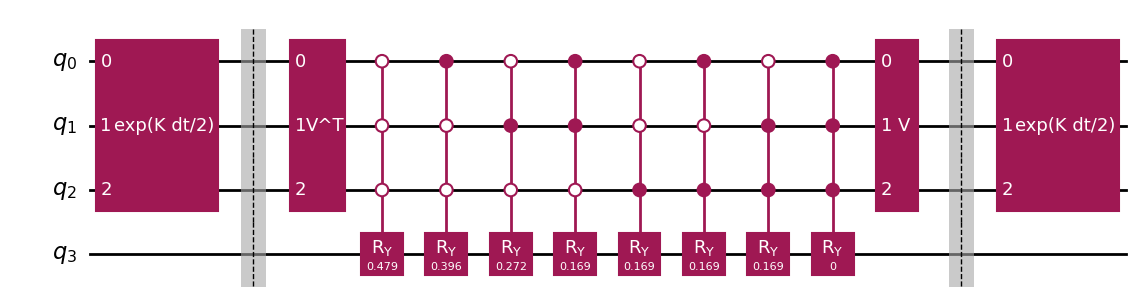


=== Step 4: verifying circuit against exact matrix math ===
||circuit (ancilla=0 block) - exact (K,S)-step||_F = 1.424e-15
Verification SUCCESS: the circuit exactly implements the dilated step.

=== Step 5: running the dilated Trotter evolution ===
Average per-step state fidelity              : 0.999358
Post-selection success probability at t=0.006s : 0.0000


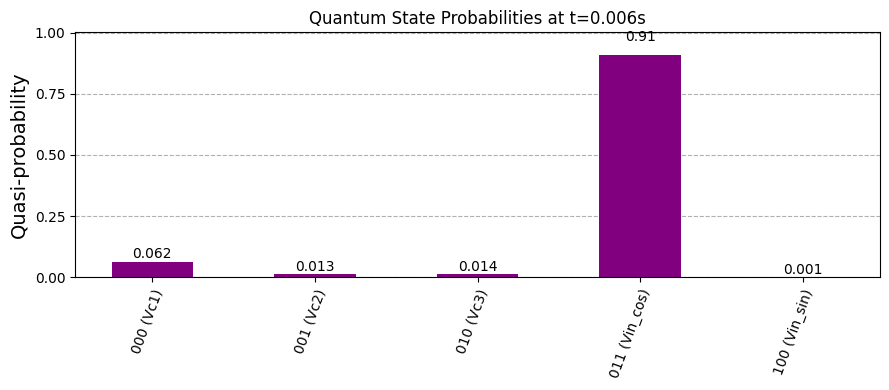


=== Step 7: measuring simulated phase shift per stage ===
Stage 1: quantum phase=-58.62 deg (|H|=0.4956)  |  scipy phase=-60.09 deg (|H|=0.4956)  |  analytic=-60.00 deg
Stage 2: quantum phase=-118.95 deg (|H|=0.2513)  |  scipy phase=-120.39 deg (|H|=0.2515)  |  analytic=-60.00 deg
Stage 3: quantum phase=-178.08 deg (|H|=0.1254)  |  scipy phase=-179.52 deg (|H|=0.1254)  |  analytic=-60.00 deg

Total output (stage 3) phase relative to Vin: -178.08 deg (target: -180.00 deg)

=== Step 7b: frequency sweep (Bode plot) ===
f=    10.00 Hz  |  stage1:  -0.02 dB,   -0.97 deg  |  stage2:  -0.02 dB,   -1.96 deg  |  stage3:  -0.03 dB,   -2.95 deg
f=    14.38 Hz  |  stage1:  -0.02 dB,   -1.40 deg  |  stage2:  -0.02 dB,   -2.82 deg  |  stage3:  -0.02 dB,   -4.25 deg
f=    20.69 Hz  |  stage1:  -0.02 dB,   -2.01 deg  |  stage2:  -0.02 dB,   -4.07 deg  |  stage3:  -0.03 dB,   -6.12 deg
f=    29.76 Hz  |  stage1:  -0.02 dB,   -2.90 deg  |  stage2:  -0.03 dB,   -5.85 deg  |  stage3:  -0.04 dB,   -8.81 d

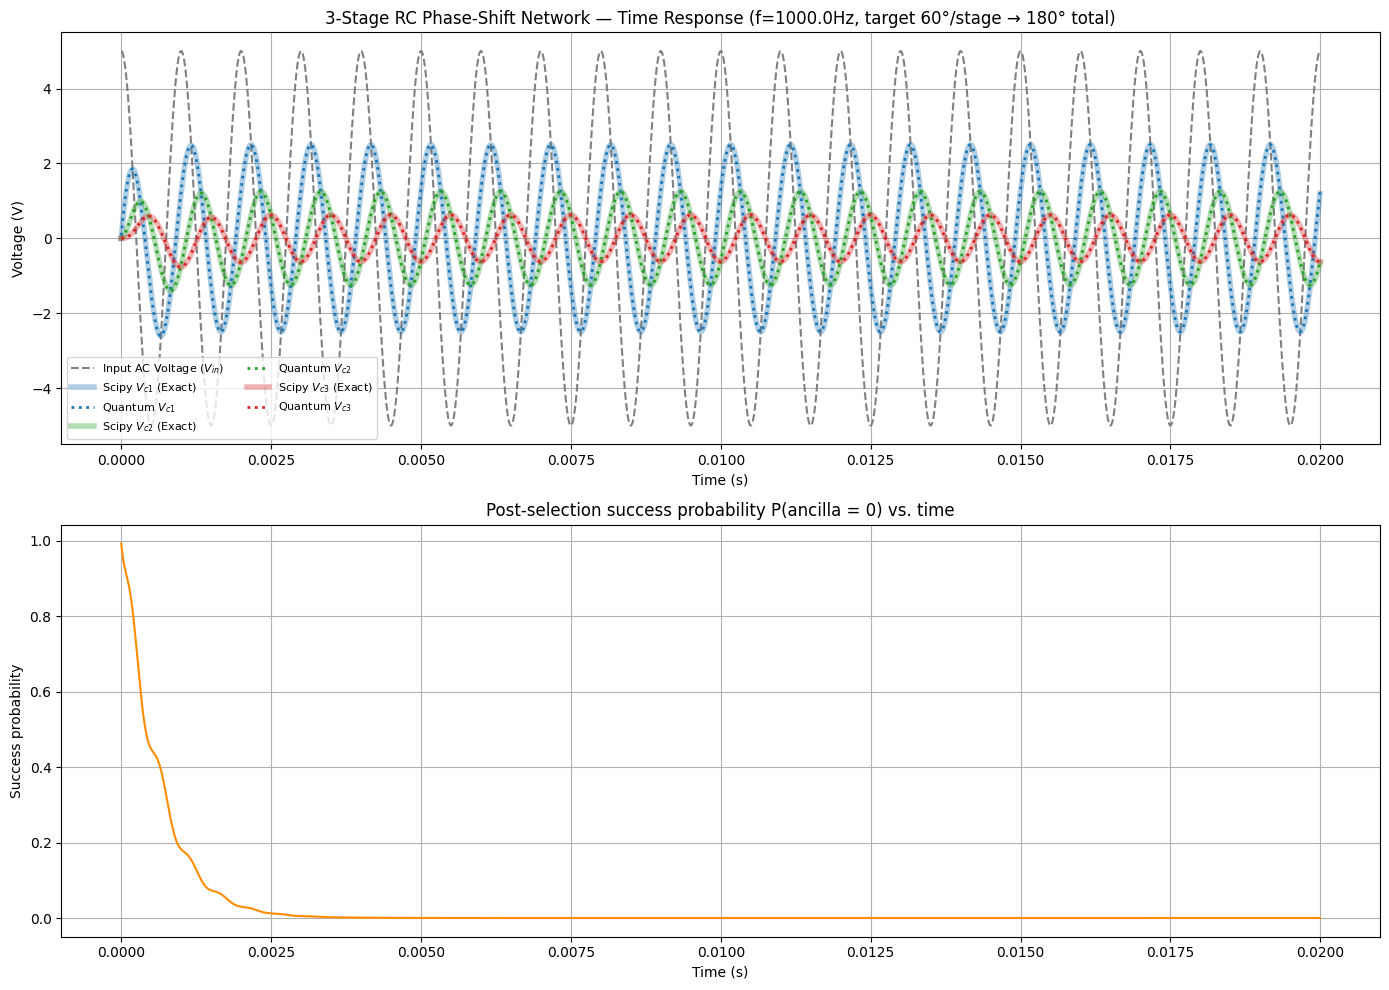

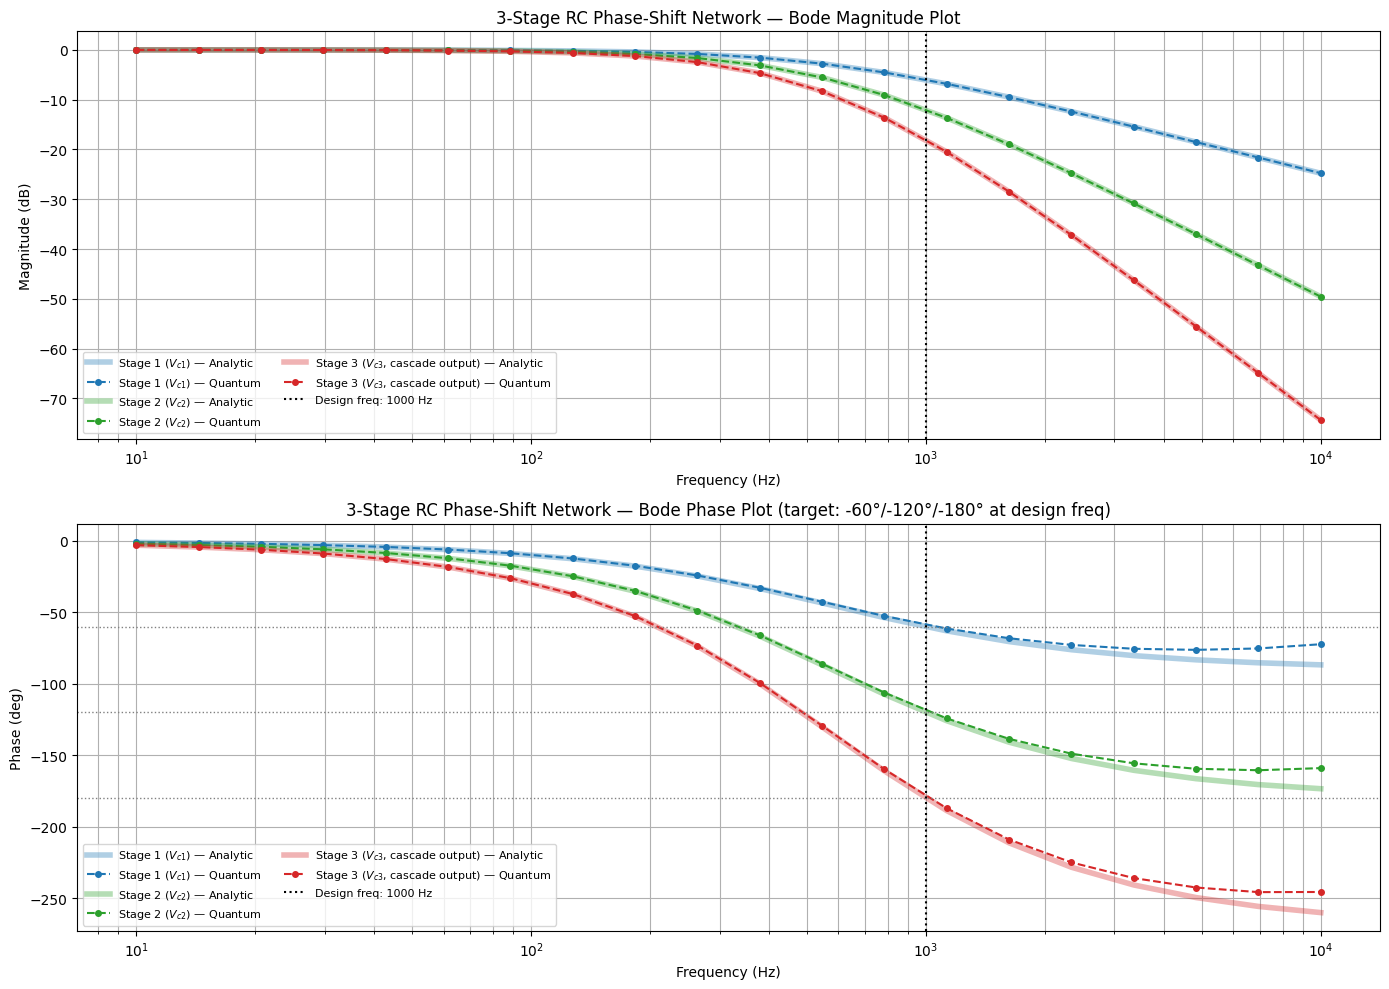


=== Final summary ===
Average per-step state fidelity   : 0.999358
Relative L2 error of Vc(t) (all 3 stages) : 2.533648e-02
Overall trajectory fidelity proxy : 0.949969
Simulated total phase shift (stage 3 vs Vin): -178.081 deg  (target: -180 deg)


In [2]:
"""
Trotterized 3-Stage RC Phase-Shift Network — Unitary Dilation Method
=======================================================================

CIRCUIT TOPOLOGY
-----------------
Three cascaded, BUFFERED single-pole RC lowpass stages: stage 1 is
driven by the AC source Vin(t)=V0*cos(wt); stage 2 is driven by stage
1's OWN output Vc1 (not by Vin directly); stage 3 is driven by stage
2's output Vc2. "Buffered" means each stage drives the next with an
ideal voltage source (no loading/current drawn back from the next
stage) -- this is the standard assumption behind the classic RC
phase-shift network and is exactly what makes each stage contribute
an independent, additive phase shift. (A directly-loaded resistive
ladder, where each stage draws real current from the previous one,
does NOT give a clean 60/60/60 split -- confirmed numerically while
deriving this: an unbuffered ladder's phases don't decouple into equal
increments no matter what R,C are chosen, because of extra
cross-loading terms in its state matrix.)

Each stage obeys its own single-pole ODE, chained to the previous
stage's output:
    dVc1/dt = (Vin - Vc1) / tau1
    dVc2/dt = (Vc1 - Vc2) / tau2
    dVc3/dt = (Vc2 - Vc3) / tau3
    tau_i = R_i * C_i

All three stages share the SAME driving frequency f0 but have
DIFFERENT R_i, C_i (as requested) chosen so that tau_i is IDENTICAL
across stages -- this is the only way to get an equal 60 deg phase
shift per stage while still using distinct component values:

    tau_needed = tan(60 deg) / w0

    Stage 1: R1=1000 ohm,  C1 solved from tau_needed
    Stage 2: R2=2200 ohm,  C2 solved from tau_needed
    Stage 3: R3=4700 ohm,  C3 solved from tau_needed

Each single stage contributes EXACTLY -60.0000 deg phase (analytically,
in steady state) and |H|=0.5 magnitude relative to ITS OWN input, so
the cascade accumulates to -60, -120, -180 deg at stages 1, 2, 3
respectively (checked numerically below against both the classical
ODE and the quantum simulation, after the initial transient settles).

STATE VECTOR (5 physical states, padded to 8 = 3 qubits)
------------------------------------------------------------
    x = [ Vc1, Vc2, Vc3, Vin_cos, Vin_sin, 0, 0, 0 ]

    dVc1/dt       = -Vc1/tau1 + Vin_cos/tau1
    dVc2/dt       = -Vc2/tau2 + Vc1/tau2
    dVc3/dt       = -Vc3/tau3 + Vc2/tau3
    dVin_cos/dt   = -omega * Vin_sin
    dVin_sin/dt   =  omega * Vin_cos

This is the direct 3-stage generalization of the single-stage
augmented state-space trick: each RC stage still only dissipates
into its OWN diagonal slot, but now A has genuine off-diagonal
couplings Vc1->Vc2 and Vc2->Vc3 (the cascade), on top of the
Vin_cos->Vc1 coupling from the original single-stage script. K and S
are recomputed for this new, larger, asymmetric A exactly the same
way as before -- the dilation method itself is agnostic to how many
coupled dissipative channels A has.

UNITARY DILATION METHOD (identical machinery to the single-stage case)
--------------------------------------------------------------------------
    K = (A - A^T)/2   -> exactly antisymmetric -> exp(K dt) EXACTLY unitary
    S = (A + A^T)/2   -> symmetric             -> non-unitary dissipative part,
                          embedded via a single ancilla qubit (dilation),
                          post-selected on ancilla = 0.

Strang splitting:  exp(K dt/2) . [S-dilation] . exp(K dt/2)
cancels the leading-order (first-order, O(dt^2)) commutator error
between the K and S sub-steps, from Baker-Campbell-Hausdorff:
    exp(K dt/2) exp(S dt) exp(K dt/2)
       = exp( (K+S)dt + O(dt^3) )
(the O(dt^2) term that would survive a naive exp(K dt)exp(S dt) product
is exactly cancelled by the symmetric split -- same reasoning as the
single-stage script, generalizes unchanged to any K,S split.)

S is diagonalized once per problem: S = V @ diag(lambda) @ V^T.
A sub-unitary block encoding can only ever shrink amplitude, so we
factor out the fastest-growing eigenmode as a classical scalar `g`
per step, and encode the remaining per-eigenmode factors
r_i = exp((lambda_i - lambda_max)*dt) <= 1 as controlled-RY rotations
onto the ancilla, post-selected on ancilla = 0.

Now needs a 3-qubit MAIN register (8-dim, holding the 5 physical
states + 3 padding zeros) + 1 ancilla = 4 qubits total for the circuit.

Run this in a Jupyter notebook (uses %matplotlib inline / display,
same as the single-stage script).
"""

# %matplotlib inline
import numpy as np
import scipy.linalg
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.circuit.library import UnitaryGate, RYGate
from qiskit.visualization import plot_histogram
from IPython.display import display

# ==========================================================
# 1. System parameters — three DIFFERENT (R,C) pairs, same tau
#    (this is the only way to get an equal 60 deg/stage split
#    while using distinct component values, as verified below)
# ==========================================================
f0 = 1000.0
omega = 2 * np.pi * f0
V0 = 5.0

target_deg_per_stage = 60.0
tau_needed = np.tan(np.radians(target_deg_per_stage)) / omega

R1 = 1000.0;  C1 = tau_needed / R1
R2 = 2200.0;  C2 = tau_needed / R2
R3 = 4700.0;  C3 = tau_needed / R3
tau1, tau2, tau3 = R1 * C1, R2 * C2, R3 * C3

t_max = 0.02
dt = 4e-6
times = np.arange(0, t_max, dt)
n_steps = len(times)
target_time = 0.006
target_step = int(target_time / dt)

print("=== Step 1: system parameters ===")
for i, (R, C, tau) in enumerate([(R1, C1, tau1), (R2, C2, tau2), (R3, C3, tau3)], start=1):
    H_i = 1 / (1 + 1j * omega * tau)
    print(f"Stage {i}: R={R} ohm, C={C:.4e} F, tau={tau:.4e} s, "
          f"analytic phase={np.degrees(np.angle(H_i)):.4f} deg, |H|={np.abs(H_i):.4f}")
Htot_analytic = 1.0
for tau in (tau1, tau2, tau3):
    Htot_analytic *= 1 / (1 + 1j * omega * tau)
print(f"Analytic total: phase={np.degrees(np.angle(Htot_analytic)):.4f} deg, "
      f"|Htot|={np.abs(Htot_analytic):.6f}")
print(f"dt/tau (worst case) = {dt/min(tau1,tau2,tau3):.4f}, dt*omega = {dt*omega:.4f} "
      f"(both small -> Strang splitting should be very accurate)")

# ==========================================================
# 2. Augmented generator A (5 physical states, padded to 8 = 3 qubits)
#    x = [Vc1, Vc2, Vc3, Vin_cos, Vin_sin, 0, 0, 0]
# ==========================================================
A_matrix = np.zeros((8, 8))
A_matrix[0, 0] = -1 / tau1; A_matrix[0, 3] = 1 / tau1          # dVc1 = (Vin_cos - Vc1)/tau1
A_matrix[1, 1] = -1 / tau2; A_matrix[1, 0] = 1 / tau2          # dVc2 = (Vc1 - Vc2)/tau2
A_matrix[2, 2] = -1 / tau3; A_matrix[2, 1] = 1 / tau3          # dVc3 = (Vc2 - Vc3)/tau3
A_matrix[3, 4] = -omega
A_matrix[4, 3] = omega
# rows/cols 5,6,7 stay zero (padding to fill the 3-qubit / 8-dim register)

print("\n=== Step 2: K / S decomposition ===")
K = (A_matrix - A_matrix.T) / 2
S = (A_matrix + A_matrix.T) / 2

lam, V_eig = np.linalg.eigh(S)
lam_max = np.max(lam)
r = np.exp((lam - lam_max) * dt)
g_step = np.exp(lam_max * dt)

print("Eigenvalues of dissipative part S:", np.round(lam, 4))
print("Per-step contraction factors r_i :", np.round(r, 6))
print(f"Classical rescale factor per step g = {g_step:.10f}")

R_half = scipy.linalg.expm(K * dt / 2)
thetas = 2 * np.arccos(np.clip(r, -1.0, 1.0))

# ==========================================================
# 3. One Strang step as an actual quantum circuit
#     (3 main qubits + 1 ancilla) — used for drawing + verification
# ==========================================================
print("\n=== Step 3: building one-step quantum circuit ===")

def build_one_step_circuit():
    qc = QuantumCircuit(4, name="strang_step")  # qubits 0,1,2 = main ; qubit 3 = ancilla
    main_qubits = [0, 1, 2]
    ancilla = 3

    qc.append(UnitaryGate(R_half, label="exp(K dt/2)"), main_qubits)
    qc.barrier()

    qc.append(UnitaryGate(V_eig.T, label="V^T"), main_qubits)
    for i, theta in enumerate(thetas):
        qc.append(RYGate(theta).control(3, ctrl_state=i), main_qubits + [ancilla])
    qc.append(UnitaryGate(V_eig, label="V"), main_qubits)
    qc.barrier()

    qc.append(UnitaryGate(R_half, label="exp(K dt/2)"), main_qubits)
    return qc

one_step_qc = build_one_step_circuit()
display(one_step_qc.draw(output='mpl', style='iqp'))

# ==========================================================
# 4. Matrix verification: circuit vs. exact math
# ==========================================================
print("\n=== Step 4: verifying circuit against exact matrix math ===")
full_unitary = Operator(one_step_qc).data       # 16x16 unitary (main ⊗ ancilla)
sub_block = full_unitary[0:8, 0:8]               # ancilla start = end = 0 block

exact_full_step = R_half @ (V_eig @ np.diag(r) @ V_eig.T) @ R_half
difference = np.linalg.norm(sub_block - exact_full_step)
print(f"||circuit (ancilla=0 block) - exact (K,S)-step||_F = {difference:.3e}")
if difference < 1e-8:
    print("Verification SUCCESS: the circuit exactly implements the dilated step.")
else:
    print("Verification FAILED — check qubit ordering / ctrl_state convention.")

# ==========================================================
# 5. Time evolution: exact classical propagation matching the circuit
#     (reuse precomputed matrices verified in step 4, same as the
#      single-stage script's approach — rebuilding the circuit
#      thousands of times would be extremely slow)
# ==========================================================
print("\n=== Step 5: running the dilated Trotter evolution ===")

def rc3_deriv(x, t):
    Vin = V0 * np.cos(omega * t)
    Vc1, Vc2, Vc3 = x
    return [(Vin - Vc1) / tau1, (Vc1 - Vc2) / tau2, (Vc2 - Vc3) / tau3]

Vc_scipy = odeint(rc3_deriv, [0.0, 0.0, 0.0], times)   # columns: Vc1,Vc2,Vc3
Vin_scipy = V0 * np.cos(omega * times)

state = np.array([0.0, 0.0, 0.0, V0, 0.0, 0.0, 0.0, 0.0])  # physical + padding, stays exactly real
classical_gain = 1.0
initial_norm = np.linalg.norm(state)

Vc_quantum = np.zeros((n_steps, 3))
success_prob = np.zeros(n_steps)
fidelities = np.zeros(n_steps)
target_probabilities = {}

for i in range(n_steps):
    state = R_half @ state
    state = V_eig @ (r * (V_eig.T @ state))
    state = R_half @ state
    classical_gain *= g_step

    Vc_quantum[i, :] = classical_gain * state[0:3]
    success_prob[i] = (np.linalg.norm(state) / initial_norm) ** 2

    exact_vec = np.array([
        Vc_scipy[i, 0], Vc_scipy[i, 1], Vc_scipy[i, 2],
        V0 * np.cos(omega * times[i]), V0 * np.sin(omega * times[i]),
        0.0, 0.0, 0.0
    ])
    exact_norm = np.linalg.norm(exact_vec)
    exact_unit = exact_vec / exact_norm if exact_norm > 0 else exact_vec
    quantum_full = classical_gain * state
    quantum_unit = quantum_full / max(np.linalg.norm(quantum_full), 1e-15)
    fidelities[i] = float(np.dot(exact_unit, quantum_unit)) ** 2

    if i == target_step:
        probs = (state / np.linalg.norm(state)) ** 2
        target_probabilities = {
            '000 (Vc1)': float(probs[0]),
            '001 (Vc2)': float(probs[1]),
            '010 (Vc3)': float(probs[2]),
            '011 (Vin_cos)': float(probs[3]),
            '100 (Vin_sin)': float(probs[4]),
            '101 (pad)': float(probs[5]),
            '110 (pad)': float(probs[6]),
            '111 (pad)': float(probs[7]),
        }

print(f"Average per-step state fidelity              : {np.mean(fidelities):.6f}")
print(f"Post-selection success probability at t={target_time}s : {success_prob[target_step]:.4f}")

# ==========================================================
# 6. Histogram at target time
# ==========================================================
clean_probs = {k: v for k, v in target_probabilities.items() if v > 1e-10}
display(plot_histogram(clean_probs, title=f"Quantum State Probabilities at t={target_time}s",
                        color='purple', figsize=(9, 4)))

# ==========================================================
# 7. Phase-shift verification: measure actual simulated phase
#    of each stage output relative to Vin, using steady-state
#    cycles (skip initial transient)
# ==========================================================
print("\n=== Step 7: measuring simulated phase shift per stage ===")

def measure_phase(vc_signal, vin_signal, t_arr, w, skip_time):
    mask = t_arr >= skip_time
    t_s = t_arr[mask]
    vc_s = vc_signal[mask]
    vin_s = vin_signal[mask]
    # in-phase / quadrature demodulation against the known drive frequency
    I_vc = np.mean(vc_s * np.cos(w * t_s)) * 2
    Q_vc = np.mean(vc_s * np.sin(w * t_s)) * 2
    phase_vc = np.degrees(np.arctan2(-Q_vc, I_vc))
    mag_vc = np.hypot(I_vc, Q_vc)
    return phase_vc, mag_vc

skip_time = 12 * max(tau1, tau2, tau3)  # let transient settle first
for i in range(3):
    ph_q, mag_q = measure_phase(Vc_quantum[:, i], Vin_scipy, times, omega, skip_time)
    ph_s, mag_s = measure_phase(Vc_scipy[:, i], Vin_scipy, times, omega, skip_time)
    print(f"Stage {i+1}: quantum phase={ph_q:.2f} deg (|H|={mag_q/V0:.4f})  |  "
          f"scipy phase={ph_s:.2f} deg (|H|={mag_s/V0:.4f})  |  analytic=-60.00 deg")

ph_q3, mag_q3 = measure_phase(Vc_quantum[:, 2], Vin_scipy, times, omega, skip_time)
print(f"\nTotal output (stage 3) phase relative to Vin: {ph_q3:.2f} deg "
      f"(target: -180.00 deg)")

# ==========================================================
# 7b. Bode plot: frequency sweep, same K/S dilation method,
#     re-derived per frequency (A depends on omega through the
#     Vin_cos/Vin_sin rotation block, tau_i's are fixed component
#     values so they do NOT change with the sweep frequency —
#     only the drive frequency omega_sweep changes, which is the
#     physically correct thing to sweep for a Bode plot)
# ==========================================================
print("\n=== Step 7b: frequency sweep (Bode plot) ===")

def run_one_frequency(omega_sweep, dt_local, n_periods_transient=15, n_periods_measure=6):
    # Build A for this sweep frequency (tau1,tau2,tau3 fixed component values)
    A_i = np.zeros((8, 8))
    A_i[0, 0] = -1 / tau1; A_i[0, 3] = 1 / tau1
    A_i[1, 1] = -1 / tau2; A_i[1, 0] = 1 / tau2
    A_i[2, 2] = -1 / tau3; A_i[2, 1] = 1 / tau3
    A_i[3, 4] = -omega_sweep
    A_i[4, 3] = omega_sweep

    K_i = (A_i - A_i.T) / 2
    S_i = (A_i + A_i.T) / 2
    lam_i, V_i = np.linalg.eigh(S_i)
    lam_i_max = np.max(lam_i)
    r_i = np.exp((lam_i - lam_i_max) * dt_local)
    log_g_i = lam_i_max * dt_local          # log of per-step classical rescale factor
    Rh_i = scipy.linalg.expm(K_i * dt_local / 2)

    period = 2 * np.pi / omega_sweep
    # cap settle time so low frequencies don't blow up step count / gain overflow —
    # RC decay settles on the tau_i timescale regardless of drive period, so
    # settling only needs to track max(tau_i), with a couple of periods as floor
    settle_time = max(n_periods_transient * max(tau1, tau2, tau3), 3 * min(period, max(tau1,tau2,tau3)*n_periods_transient))
    measure_time = n_periods_measure * period
    total_time = settle_time + measure_time
    n_steps_i = int(total_time / dt_local)
    settle_steps = int(settle_time / dt_local)

    state_i = np.array([0.0, 0.0, 0.0, V0, 0.0, 0.0, 0.0, 0.0])
    log_gain_i = 0.0   # accumulate in log-space to avoid overflow over many steps

    t_hist = np.zeros(n_steps_i - settle_steps)
    vc_hist = np.zeros((n_steps_i - settle_steps, 3))

    for step in range(n_steps_i):
        state_i = Rh_i @ state_i
        state_i = V_i @ (r_i * (V_i.T @ state_i))
        state_i = Rh_i @ state_i
        log_gain_i += log_g_i

        if step >= settle_steps:
            idx = step - settle_steps
            t_hist[idx] = step * dt_local
            vc_hist[idx, :] = np.exp(log_gain_i) * state_i[0:3]

    mags = np.zeros(3)
    phases = np.zeros(3)
    for j in range(3):
        I_c = np.mean(vc_hist[:, j] * np.cos(omega_sweep * t_hist)) * 2
        Q_c = np.mean(vc_hist[:, j] * np.sin(omega_sweep * t_hist)) * 2
        mags[j] = np.hypot(I_c, Q_c)
        phases[j] = np.degrees(np.arctan2(-Q_c, I_c))
    return mags, phases

sweep_freqs = np.logspace(1, 4, 20)   # 10 Hz to 10 kHz
dt_sweep = 4e-6

quantum_mag_db = np.zeros((len(sweep_freqs), 3))
quantum_phase_deg = np.zeros((len(sweep_freqs), 3))

for k, f_sweep in enumerate(sweep_freqs):
    w_sweep = 2 * np.pi * f_sweep
    mags, phases = run_one_frequency(w_sweep, dt_sweep)
    quantum_mag_db[k, :] = 20 * np.log10(np.maximum(mags / V0, 1e-16))
    quantum_phase_deg[k, :] = phases
    print(f"f={f_sweep:9.2f} Hz  |  "
          f"stage1: {quantum_mag_db[k,0]:6.2f} dB, {quantum_phase_deg[k,0]:7.2f} deg  |  "
          f"stage2: {quantum_mag_db[k,1]:6.2f} dB, {quantum_phase_deg[k,1]:7.2f} deg  |  "
          f"stage3: {quantum_mag_db[k,2]:6.2f} dB, {quantum_phase_deg[k,2]:7.2f} deg")

# Unwrap the measured phase curves (arctan2 wraps at +/-180 deg; the
# underlying physical phase for these stages decreases monotonically
# past -180 deg as frequency increases, e.g. stage 3 keeps rotating
# beyond -180 deg -- unwrap column-by-column, low-to-high frequency)
quantum_phase_deg = np.unwrap(quantum_phase_deg, axis=0, period=360)

# Analytic reference Bode curves (single-pole stages, exact formulas)
def analytic_H(tau_i, w):
    return 1.0 / (1 + 1j * w * tau_i)

w_sweep_arr = 2 * np.pi * sweep_freqs
H1_analytic = analytic_H(tau1, w_sweep_arr)
H2_analytic = H1_analytic * analytic_H(tau2, w_sweep_arr)
H3_analytic = H2_analytic * analytic_H(tau3, w_sweep_arr)
analytic_mag_db = np.stack([
    20 * np.log10(np.abs(H1_analytic)),
    20 * np.log10(np.abs(H2_analytic)),
    20 * np.log10(np.abs(H3_analytic)),
], axis=1)
analytic_phase_deg = np.stack([
    np.degrees(np.unwrap(np.angle(H1_analytic))),
    np.degrees(np.unwrap(np.angle(H2_analytic))),
    np.degrees(np.unwrap(np.angle(H3_analytic))),
], axis=1)

# ==========================================================
# 8. Final graphs: time domain (all 3 stages) & Bode plots
# ==========================================================
print("\n=== Step 8: generating final output graphs ===")
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(times, Vin_scipy, label='Input AC Voltage ($V_{in}$)', color='gray', linestyle='--')
colors = ['tab:blue', 'tab:green', 'tab:red']
for i in range(3):
    plt.plot(times, Vc_scipy[:, i], color=colors[i], linewidth=4, alpha=0.35,
              label=f'Scipy $V_{{c{i+1}}}$ (Exact)')
    plt.plot(times, Vc_quantum[:, i], color=colors[i], linestyle=':', linewidth=2,
              label=f'Quantum $V_{{c{i+1}}}$')
plt.title(f'3-Stage RC Phase-Shift Network — Time Response '
          f'(f={f0}Hz, target 60°/stage → 180° total)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend(ncol=2, fontsize=8)
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(times, success_prob, color='darkorange')
plt.title("Post-selection success probability P(ancilla = 0) vs. time")
plt.xlabel("Time (s)")
plt.ylabel("Success probability")
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================================
# 8b. Bode plot: magnitude and phase, all 3 stages, quantum vs analytic
# ==========================================================
plt.figure(figsize=(14, 10))
stage_labels = ['Stage 1 ($V_{c1}$)', 'Stage 2 ($V_{c2}$)', 'Stage 3 ($V_{c3}$, cascade output)']

plt.subplot(2, 1, 1)
for j in range(3):
    plt.semilogx(sweep_freqs, analytic_mag_db[:, j], color=colors[j], linewidth=4, alpha=0.35,
                 label=f'{stage_labels[j]} — Analytic')
    plt.semilogx(sweep_freqs, quantum_mag_db[:, j], color=colors[j], marker='o',
                 linestyle='--', linewidth=1.5, markersize=4,
                 label=f'{stage_labels[j]} — Quantum')
plt.axvline(x=f0, color='black', linestyle=':', label=f'Design freq: {f0:.0f} Hz')
plt.title('3-Stage RC Phase-Shift Network — Bode Magnitude Plot')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, which='both', ls='-')

plt.subplot(2, 1, 2)
for j in range(3):
    plt.semilogx(sweep_freqs, analytic_phase_deg[:, j], color=colors[j], linewidth=4, alpha=0.35,
                 label=f'{stage_labels[j]} — Analytic')
    plt.semilogx(sweep_freqs, quantum_phase_deg[:, j], color=colors[j], marker='o',
                 linestyle='--', linewidth=1.5, markersize=4,
                 label=f'{stage_labels[j]} — Quantum')
plt.axhline(y=-60, color='gray', linestyle=':', linewidth=1)
plt.axhline(y=-120, color='gray', linestyle=':', linewidth=1)
plt.axhline(y=-180, color='gray', linestyle=':', linewidth=1)
plt.axvline(x=f0, color='black', linestyle=':', label=f'Design freq: {f0:.0f} Hz')
plt.title('3-Stage RC Phase-Shift Network — Bode Phase Plot '
          '(target: -60°/-120°/-180° at design freq)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (deg)')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, which='both', ls='-')

plt.tight_layout()
plt.show()

# ==========================================================
# 9. Final fidelity + phase-accuracy summary
# ==========================================================
rel_error = np.linalg.norm(Vc_quantum - Vc_scipy) / np.linalg.norm(Vc_scipy)
print("\n=== Final summary ===")
print(f"Average per-step state fidelity   : {np.mean(fidelities):.6f}")
print(f"Relative L2 error of Vc(t) (all 3 stages) : {rel_error:.6e}")
print(f"Overall trajectory fidelity proxy : {(1-rel_error)**2:.6f}")
print(f"Simulated total phase shift (stage 3 vs Vin): {ph_q3:.3f} deg  (target: -180 deg)")
